In [36]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno

In [38]:
# Configuration and paths
min_range = -0
max_range = +500

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
…,…,…,…,…
"""splicing""","""delta_score""","""#00A99D""","""SpliceAI""",1
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",1


In [40]:
# Beltran et al. 2025
exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250904_Beltran_447aPCA.parquet").rename({
    'dms_type': 'annotation',
    'dms_score': 'annotation_score'
})

exp_annos = ['fitness','FoldX','thermoMPNN']
exp_annos_df = pl.DataFrame({
    "category": ['aPCA', 'missense', 'missense'],
    'annotation': exp_annos,
    "color": ['gray', '#FF8800', '#FFBB88'],
    'label': ['aPCA fitness','FoldX','thermoMPNN'],
    'annotation_dir': [1, 1, 1],
})

anno_config_df = pl.concat([anno_config_df, exp_annos_df])

exp_df = exp_df.filter(
    pl.col('annotation').is_in(exp_annos)
).with_columns(
    pl.col('annotation_score').cast(pl.Float32),
).drop_nulls()

# [mutant, region] combinations where all of the exp_annos are present
valid_combos = (
    exp_df
    .group_by(["mutant", "region"])
    .agg(pl.col("annotation").n_unique().alias("n_annos"))
    .filter(pl.col("n_annos") == len(exp_annos))
    .select(["mutant", "region"])
)

# Join back if you want the filtered full dataset
exp_df = exp_df.join(valid_combos, on=["mutant", "region"])
exp_df

region,gene_name,mutant,annotation,annotation_score
str,str,str,str,f32
"""ENSG00000128610""","""FEZF1""","""A300C""","""fitness""",0.085555
"""ENSG00000128610""","""FEZF1""","""A300D""","""fitness""",0.092028
"""ENSG00000128610""","""FEZF1""","""A300E""","""fitness""",0.10999
"""ENSG00000128610""","""FEZF1""","""A300F""","""fitness""",0.064676
"""ENSG00000128610""","""FEZF1""","""A300G""","""fitness""",0.076879
…,…,…,…,…
"""ENSG00000186472""","""PCLO""","""W1104R""","""thermoMPNN""",1.99153
"""ENSG00000186472""","""PCLO""","""W1104S""","""thermoMPNN""",2.117514
"""ENSG00000186472""","""PCLO""","""W1104T""","""thermoMPNN""",1.988062


In [41]:
anno = pl.read_parquet("/home/dnanexus/data_dir/dms_coding.ag/annotations.parquet")
existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.filter(
    pl.col('consequence_missense_variant') == 1
).select(
    set(['id', 'mutant', 'region']).union(set(existing_annos))
)

val_ids = anno[['mutant', 'id', 'region']].unique().join(exp_df[['mutant', 'region']].unique(), on=['mutant', 'region'], how='inner')
val_ids

/tmp/ipykernel_308900/2282154104.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


mutant,id,region
str,str,str
"""R181P""","""chr19:48714547:C:G""","""ENSG00000176909"""
"""V494I""","""chr1:3731061:G:A""","""ENSG00000078900"""
"""R125Q""","""chr3:186538859:C:T""","""ENSG00000213139"""
"""V1086M""","""chr7:83134294:C:T""","""ENSG00000186472"""
"""D165E""","""chr16:983800:C:G""","""ENSG00000005513"""
…,…,…
"""A251V""","""chr1:18691919:C:T""","""ENSG00000009709"""
"""S983P""","""chr7:102204430:T:C""","""ENSG00000257923"""
"""R150H""","""chr17:7203480:C:T""","""ENSG00000132535"""


In [42]:
melted_anno = anno.join(
    val_ids, 
    on=['mutant', 'id', 'region'], 
    how='inner'
).unpivot(
    index=["id", "mutant", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
).join(
    exp_df[['mutant', 'region']].unique(), 
    on=['mutant', 'region'], 
    how='inner'
)

exp_df_subset = exp_df.join(val_ids.unique(), on=['mutant', 'region'], how='inner')[melted_anno.columns]
melted_anno = pl.concat([melted_anno, exp_df_subset])

melted_anno

id,mutant,region,annotation,annotation_score
str,str,str,str,f32
"""chr17:29252108:T:C""","""I87T""","""ENSG00000108255""","""am_pathogenicity""",0.7655
"""chr17:29252108:T:C""","""I87T""","""ENSG00000108255""","""esmscoremissense""",-9.436
"""chr17:29252108:T:C""","""I87T""","""ENSG00000108255""","""cadd_raw""",4.30512
"""chr17:29252108:T:C""","""I87T""","""ENSG00000108255""","""gpn_score""",-5.27
"""chr17:29252108:T:C""","""I87T""","""ENSG00000108255""","""zooverphylop""",4.69
…,…,…,…,…
"""chr7:83134297:G:T""","""Q1085K""","""ENSG00000186472""","""thermoMPNN""",0.07325
"""chr7:83134266:G:A""","""T1095I""","""ENSG00000186472""","""thermoMPNN""",0.220304
"""chr7:83134255:T:C""","""T1099A""","""ENSG00000186472""","""thermoMPNN""",-0.026792


In [ ]:
appv = pl.read_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_dmsCoding_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:1327326:G:A""","""red_blood_cell_erythrocyte_dis…",1,-0.391999,null
"""chr1:1333534:G:A""","""red_blood_cell_erythrocyte_dis…",3,-0.802695,1.69287
"""chr1:1334123:C:G""","""mean_platelet_thrombocyte_volu…",375,0.011048,0.877053
"""chr1:1340109:T:C""","""mean_platelet_thrombocyte_volu…",26,-0.294736,0.983572
"""chr1:8356202:C:T""","""mean_platelet_thrombocyte_volu…",13,-0.234435,0.737698
…,…,…,…,…
"""chr22:40869007:T:C""","""red_blood_cell_erythrocyte_dis…",1,-0.631422,null
"""chr22:41177819:A:T""","""mean_corpuscular_haemoglobin_c…",1,0.663226,null
"""chr22:41155038:G:A""","""mothers_age_at_death_int""",1,0.046959,null


In [44]:
# Read the full Genebass results
# p-value thresholds
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        significant = (pl.col('Pvalue') < pval_cutoffs['skato']) | (pl.col('Pvalue_Burden') < pval_cutoffs['burden']),
        phenotype = pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.replace_all('-', '').str.replace_all("'", '').str.replace_all(',', '').str.to_lowercase() + '_int',
        region = pl.col('gene_id'),
        gene_name = pl.col('gene_symbol'),
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('trait_type') == 'continuous') &
        # (pl.col('annotation').str.contains('pLoF'))
        (pl.col('annotation') == 'pLoF')
    )
    .select(['region', 'gene_name', 'phenotype', 'trait_type'])
    .unique()
)

# Keep the top hit per gene
# gb_pl = gb_pl.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = gb_pl[['region', 'gene_name', 'phenotype', 'trait_type']].unique()

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")

gene_trait_df = gb_pl.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner')
gene_trait_df = gene_trait_df.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
    sign_agreement = (pl.col('loftee_corr')*pl.col('beta') > 0) & (pl.col('loftee_corr').is_not_nan()),
    corr_dir = (pl.col('loftee_corr')/pl.col('loftee_corr').abs())
)

# TODO: We don't cover all genebass significant genes, so we need to filter out nans (LOFTEE correlations missing)
gene_trait_df = gene_trait_df.filter(pl.col('sign_agreement')==1)
gene_trait_df

region,gene_name,phenotype,trait_type,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement,corr_dir
str,str,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,bool,f32
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""","""continuous""",-0.195409,9.1637e-8,1280,1280,70,-0.129833,"[62, 54, … 1]","""chr1:176710105:CG:C""",62,0.0546875,-4.681031,0.000003,true,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""","""continuous""",-0.397279,0.006626,530,530,13,-0.219682,"[1, 1, … 1]","""chr11:14493694:G:A""",1,0.024528,-5.174315,3.2549e-7,true,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""","""continuous""",-0.058463,0.000305,1098,1098,106,-0.036752,"[627, 129, … 1]","""chr14:58428357:T:TC""",627,0.096539,-1.217545,0.223659,true,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""","""continuous""",-0.436618,6.0395e-11,2030,2030,55,-0.199516,"[40, 37, … 1]","""chr15:88843601:CG:C""",40,0.027094,-9.169199,1.1354e-19,true,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""","""continuous""",-0.412619,2.8609e-8,1093,1093,46,-0.154286,"[13, 7, … 1]","""chr15:98924680:CAA:C""",13,0.042086,-5.157856,2.9651e-7,true,-1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""","""continuous""",0.952411,1.8038e-41,315,315,16,0.174576,"[149, 5, … 1]","""chr6:49636655:C:T""",149,0.050794,3.136737,0.001871,true,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""continuous""",0.656849,2.1682e-10,1392,1392,34,0.269449,"[18, 12, … 1]","""chr8:41672574:CTG:C""",18,0.024425,10.431616,1.3985e-24,true,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""",0.176348,2.1188e-7,2047,2047,225,0.035972,"[109, 67, … 1]","""chr9:77339540:C:CT""",109,0.109917,1.627776,0.103726,true,1.0


In [45]:
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

(2385, 5) (30681, 4)


/tmp/ipykernel_308900/2529300033.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_308900/2529300033.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


In [46]:
# Join df all the dataframes with pairs to restrict to valid (gene_id, phenotype)
# pheno_anno = appv_flt.join(anno_flt, on='id')
# pheno_anno = pheno_anno.join(gene_trait_df, on=['region', 'phenotype'])
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)
pheno_anno

(7092, 24)


id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_name,trait_type,beta,rvat_pval,n_variants,n_variants_nonull,n_plof_variants,loftee_corr,n_individuals_plof,top_plof_var,top_plof_var_count,plof_prop,t_stat,corr_pval,sign_agreement,corr_dir,mean_pheno_value_rank,annotation_score_rank
str,str,u32,f32,str,str,str,f32,str,str,f64,f64,u64,u64,i64,f32,list[u32],str,u32,f64,f64,f64,bool,f32,u64,u64
"""chr3:58153504:C:T""","""gamma_glutamyltransferase_int""",31,0.073296,"""T2166M""","""ENSG00000136068""","""am_pathogenicity""",0.082,"""FLNB""","""continuous""",-0.217856,0.000008,1915,1915,100,-0.048037,"[53, 32, … 1]","""chr3:58097836:C:T""",53,0.052219,-2.10347,0.035555,true,-1.0,57,16
"""chr3:58153504:C:T""","""gamma_glutamyltransferase_int""",31,0.073296,"""T2166M""","""ENSG00000136068""","""esmscoremissense""",-5.52,"""FLNB""","""continuous""",-0.217856,0.000008,1915,1915,100,-0.048037,"[53, 32, … 1]","""chr3:58097836:C:T""",53,0.052219,-2.10347,0.035555,true,-1.0,57,36
"""chr3:58153504:C:T""","""gamma_glutamyltransferase_int""",31,0.073296,"""T2166M""","""ENSG00000136068""","""cadd_raw""",5.018699,"""FLNB""","""continuous""",-0.217856,0.000008,1915,1915,100,-0.048037,"[53, 32, … 1]","""chr3:58097836:C:T""",53,0.052219,-2.10347,0.035555,true,-1.0,57,85
"""chr3:58153504:C:T""","""gamma_glutamyltransferase_int""",31,0.073296,"""T2166M""","""ENSG00000136068""","""gpn_score""",-6.06,"""FLNB""","""continuous""",-0.217856,0.000008,1915,1915,100,-0.048037,"[53, 32, … 1]","""chr3:58097836:C:T""",53,0.052219,-2.10347,0.035555,true,-1.0,57,79
"""chr3:58153504:C:T""","""gamma_glutamyltransferase_int""",31,0.073296,"""T2166M""","""ENSG00000136068""","""zooverphylop""",8.88,"""FLNB""","""continuous""",-0.217856,0.000008,1915,1915,100,-0.048037,"[53, 32, … 1]","""chr3:58097836:C:T""",53,0.052219,-2.10347,0.035555,true,-1.0,57,87
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:62910000:C:T""","""hip_circumference_int""",4,0.508349,"""R287H""","""ENSG00000101191""","""zooverphylop""",8.767,"""DIDO1""","""continuous""",0.738026,4.0541e-10,2009,2009,23,0.120922,"[2, 1, … 1]","""chr20:62893945:GA:G""",2,0.011448,5.45728,5.4331e-8,true,1.0,16,16
"""chr20:62910000:C:T""","""hip_circumference_int""",4,0.508349,"""R287H""","""ENSG00000101191""","""verphylop""",5.634,"""DIDO1""","""continuous""",0.738026,4.0541e-10,2009,2009,23,0.120922,"[2, 1, … 1]","""chr20:62893945:GA:G""",2,0.011448,5.45728,5.4331e-8,true,1.0,16,10
"""chr20:62910000:C:T""","""hip_circumference_int""",4,0.508349,"""R287H""","""ENSG00000101191""","""fitness""",0.113421,"""DIDO1""","""continuous""",0.738026,4.0541e-10,2009,2009,23,0.120922,"[2, 1, … 1]","""chr20:62893945:GA:G""",2,0.011448,5.45728,5.4331e-8,true,1.0,16,9


In [47]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score_rank"))
    )
    # .with_columns(
    #     pl.col("correlation").abs().alias("abs_corr"),
    # )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
annos_w_inconsistent_assocs = (
    correlation_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    correlation_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

# Join with beta directions and annotation directions
correlation_df = correlation_df.join(
    gene_trait_df[['region', 'phenotype', 'beta', 'corr_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
).with_columns(
    corr_beta = pl.col('correlation')*pl.col('corr_dir')*pl.col('annotation_dir')
)
correlation_df

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,beta,corr_dir,category,color,label,annotation_dir,corr_beta
str,str,str,str,u64,f64,f64,f32,str,str,str,i64,f64
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""verphylop""",16,-0.129412,0.738026,1.0,"""conservation""","""#440154""","""Vertebrate PhyloP""",1,-0.129412
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""fitness""",16,0.385294,0.738026,1.0,"""aPCA""","""gray""","""aPCA fitness""",1,0.385294
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""esmscoremissense""",16,-0.029412,0.738026,1.0,"""missense""","""#feb72d""","""ESM1v""",-1,0.029412
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""cadd_raw""",16,0.326471,0.738026,1.0,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.326471
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""gpn_score""",16,-0.091176,0.738026,1.0,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.091176
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""gpn_score""",29,0.202463,0.656849,1.0,"""conservation""","""#942c80""","""GPN-MSA""",-1,-0.202463
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""FoldX""",29,-0.220197,0.656849,1.0,"""missense""","""#FF8800""","""FoldX""",1,-0.220197
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""esmscoremissense""",29,0.231034,0.656849,1.0,"""missense""","""#feb72d""","""ESM1v""",-1,-0.231034


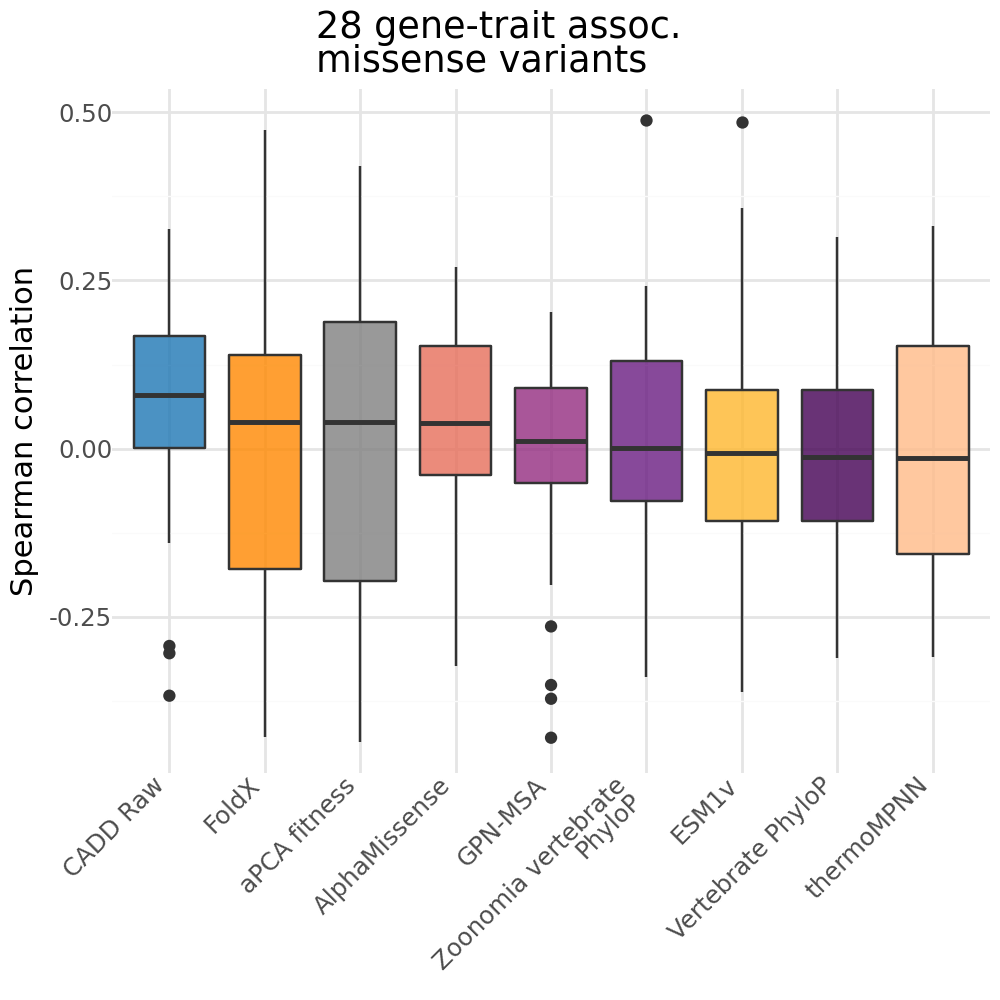

In [53]:
med_df = correlation_df.drop_nans().group_by("label").agg(
    median_corr_beta = pl.col("corr_beta").median(),
)

corr_pd = med_df.join(correlation_df, on='label').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=False)['label'].unique(),
    ordered=True
)

# Define colors
color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x='label', y='corr_beta', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_continuous(limits=[-0.5, 0.6]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Spearman correlation',
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc. \
        \nmissense variants"
    ) +
    theme(
        figure_size=(5, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [52]:
import itertools
from scipy.stats import wilcoxon

annotations = correlation_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = correlation_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = correlation_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "gene_trait_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05)

/tmp/ipykernel_308900/2641523769.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""cadd_raw""","""gpn_score""",28,100.0,0.017887
"""am_pathogenicity""","""gpn_score""",28,106.0,0.026357


## Single gene trait associtaion plot

In [ ]:
method = 'pearson'
annotation = 'am_pathogenicity'
gene_name = 'GCK'
phenotype = 'glycated_haemoglobin_hba1c_int'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)

# Old code

### Anno against anno plot

In [50]:
anno1 = 'am_pathogenicity'
anno2 = 'cadd_raw'
anno1 = 'HXK4_HUMAN_Gersing_2022_activity'
anno2 = 'HXK4_HUMAN_Gersing_2023_abundance'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == 'glycated_haemoglobin_hba1c_int') &
    (pl.col('annotation').is_in([anno1, anno2]))
    # (pl.col('annotation').str.contains('HXK4'))
).pivot(
    index = ['id', 'mean_pheno_value', 'mean_pheno_value_rank'],
    on='annotation',
    values='annotation_score'
)

(
    ggplot(sc_df, aes(x=anno1, y=anno2)) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=anno1, #"DMS activity",
        y=anno2 #"DMS abundance"
    ) +
    annotate(
        "text", 
        x=3.5, y=0.1,
        label=f"Spearman r = {sc_df.select(pl.corr(anno1, anno2, method='spearman')).item():.2f}",
        size=10, color='black'
    ) +
    theme(figure_size=(5, 4))
)

ColumnNotFoundError: unable to find column "HXK4_HUMAN_Gersing_2022_activity"; valid columns: ["id", "mean_pheno_value", "mean_pheno_value_rank"]

### Facet by n_variant bins

In [ ]:
n_cuts = 5
corr_pd['n_var_quantile'] = pd.qcut(corr_pd['n_variants'], n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)])
corr_pd['n_var_quantile'].value_counts()

n_var_quantile
1    289
4    187
3    170
5    153
2    119
Name: count, dtype: int64

/tmp/ipykernel_1043668/740667702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


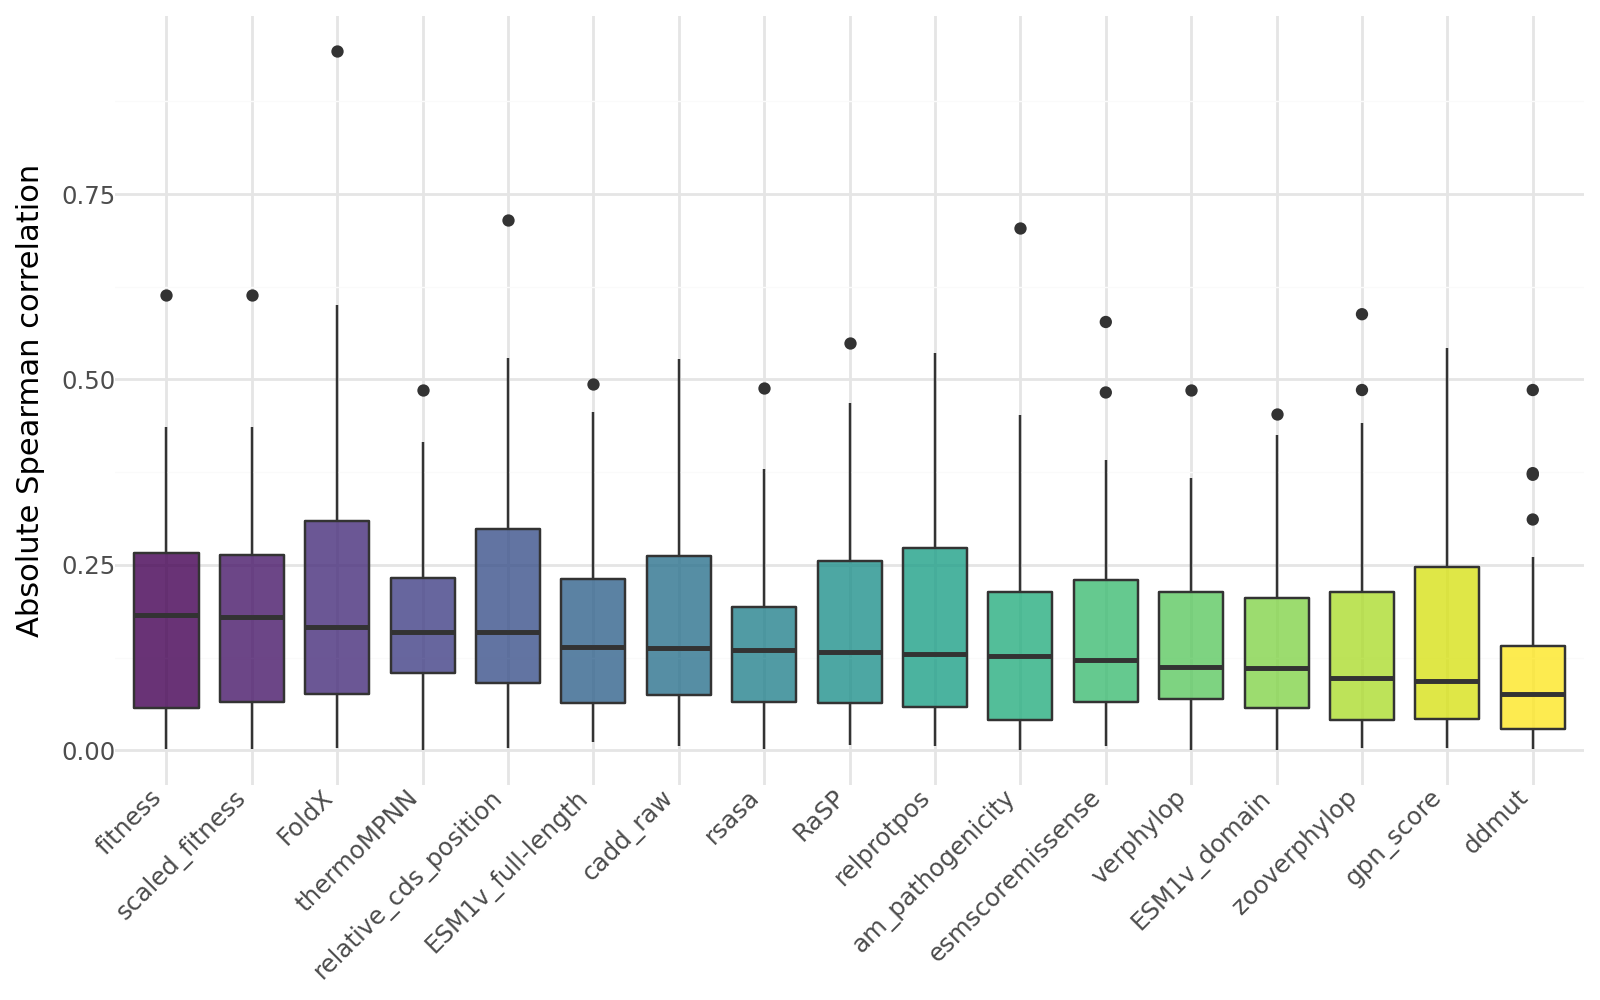

In [ ]:
corr_q1 = corr_pd[corr_pd[f'n_var_quantile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(8)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Debugging

In [ ]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(melted_anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)

gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner').with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)

gene_trait_df